## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nathan Brence

**Date:** 10/2/2026

### Question 1

1. Classification is a statistical method that predicts class or category, while regression involves predicting a numerical outcome
2. A confusion table is a matrix that counts and sorts observations based on their actual class and predicted class. It's useful for understanding a model's performance because it provides context into its accuracy, revealing which classes are predicted correctly and which are often mistaken for other categories. 
3. The SSE (Sum of Squared Errors) of a model, in the most literal definition, calculates the sum of the squared distances (or residuals) of each datapoint from a model's regression line. Essentially, SSE quantifies the prediction error in a linear model. 
4. Overfitting and underfitting can be thought of as two sides of the same coin, and that coin is models . Regarding the KNN algorithm, using a very small k-value may result in overfitting, in which the model incorporates noise into its predictions rather than actual patterns in the data. Comversely, an excessively large k-value could lead to underfitting, where the model considers so many neighboring data points that it generates nearly identical predictions for each observation.
5. Splitting the data and choosing k based on evaluation of error metrics on the test dataset improves model performance by increasing a model's generalization, or ability to perform prediction on data it wasn't trained on. Using the training dataset to configure the model and running an algorithm to find k in relation to SSE or accuracy score on the test dataset (which, in this case, is unforeseen data), one can create a model that has the best chances of being applicable to new sources of data in practice.
6. Using a class label as a prediction is effective because it's much easier to interpret and implement into practice due to its simplicity, but it also possesses the weakness of ignoring confidence of each prediction into the model. In other words, a class label with 50.1% confidence is treated the same as one with 100% confidence, throwing away nuanced data patterns in favor of simplicity. A probability distribution of class labels, however, preserves this uncertainty and allows for a more robust persepective of a model's classification. The downside to this is that such a method is difficult to implement into practice, with the additional weakness of poor interpretation stemming from its complexity.

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 
Missing Values: 0

count    338.000000
mean       0.503550
std        0.344244
min        0.000000
25%        0.200000
50%        0.600000
75%        0.800000
max        1.000000
Name: soil, dtype: float64 
Missing Values: 0

count    338.000000
mean       0.430634
std        0.195819
min        0.197734
25%        0.309737
50%        0.359516
75%        0.482628
max        0.999999
Name: voltage, dtype: float64 
Missing Values: 0

count    338.000000
mean       0.508876
std        0.306043
min        0.000000
25%        0.272727
50%        0.545455
75%        0.727273
max        1.000000
Name: height, dtype: float64 
Missing Values: 0



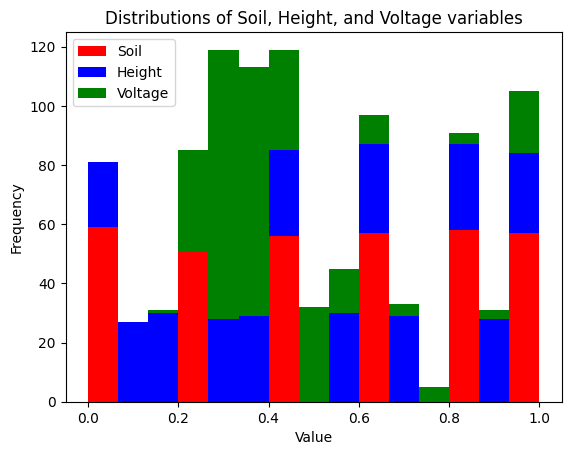

In [ ]:
# Question 2
# Part 1

#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from matplotlib import pyplot as plt

#load csv into mines variable
mines = pd.read_csv("land_mines.csv")

#summarize type variable using value_counts()
m_type = mines["mine_type"].value_counts()

#obtain info on numerical variables using describe()
soil = mines["soil"].describe()
volt = mines["voltage"].describe()
height = mines["height"].describe()

#print each summarization and amount of missing values
print(m_type, "\nMissing Values: " + str(m_type.isna().sum())+ "\n")
print(soil, "\nMissing Values: " + str(soil.isna().sum()) + "\n")
print(volt, "\nMissing Values: " + str(volt.isna().sum()) + "\n")
print(height, "\nMissing Values: " + str(height.isna().sum()) + "\n")

#create stacked histogram of numerical variables to compare distributions
plt.hist([mines["soil"], mines["height"], mines["voltage"]], bins=15, stacked=True, color=["red", "blue", "green"], label=["Soil", "Height", "Voltage"])
plt.title("Distributions of Soil, Height, and Voltage variables")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()

In [45]:
# Question 2
# Part 2

#Define x and y values based on above description, then split 50/50 with test_size=0.5
x_vals = mines[["voltage", "height", "soil"]]
y_vals = mines["mine_type"]
x_train, x_test, y_train, y_test = train_test_split(x_vals, y_vals, test_size=0.5, random_state=26)

#We can observe from the above attribute summaries that they're all already between 0 and 1, so no scaling is necessary


In [46]:
# Question 2
# Part 3

#utilize following algorithm to find k value that maximizes the accuracy of the test dataset (k_star): Returns 3
#use range of 1 to 10 for k candidates to ensure small dataset isn't underfit

k_vals = np.arange(1, 11)
test_acc = []
for k in k_vals:
    k_candidate = KNeighborsClassifier(n_neighbors=int(k))
    k_candidate.fit(x_train, y_train)
    test_hat = k_candidate.predict(x_test)
    test_acc.append(accuracy_score(y_test, test_hat))
k_star = int(k_vals[np.argmax(test_acc)])
print(f"Optimal k-value = {k_star}")

#create the kNN classifier utilizing the k_star value for k, generating predicted values from test data
model = KNeighborsClassifier(n_neighbors=k_star).fit(x_train, y_train)
y_pred = model.predict(x_test)

Optimal k-value = 3


As mentioned above, I used an algorithm to find the k-value that maximizes the accuracy score of the test dataset, utilizing only a small range of 1 to 10 for k-value candidates to avoid underfitting the model.

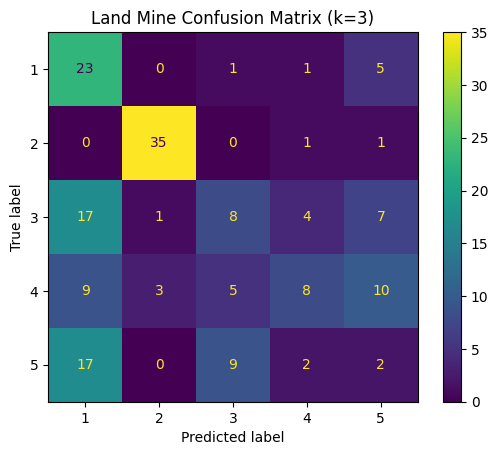

In [47]:
# Question 2
# Part 4
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
display.plot()
plt.title("Land Mine Confusion Matrix (k=3)")
plt.show()

According to the confusion matrix, the model is accurate in many respects, predicting type 1 and 2 mines to an extremely precise extent as evident by the low number of false negatives. On the other hand, the other three categories (3, 4, and 5) have serious flaws in accuracy with this model, with many of them being marked as being within the type 1 category and each having less than 10 (out of ~50 each) being predicted correctly.

### Question 2, Part 5
With reference to the above confusion matrix, the only category of mine that can be consistently predicted correctly is type 2. This is because type 2 is the only category with a small number of false positive (observation is not type 2, but predicted as such) and false negative predictions (observation is type 2, but not predicted as such). Some categories, such as type 1, have too many false positives for the model to be applied unquestionably in practice. Other classes, like types 3, 4, and 5, produce generally inaccurate predictions since the model's predictions result in a high quantity of false positives and false negatives within these categories. Hence, my advice to anyone applying this model to a real-world minefield would be to trust the model when it predicts a mine is type 2, but do not take any other class prediction at face value and perform additional research to confirm the category of mine.  

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. [Paste prompt]
2. [Paste follow-up prompt]

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [48]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]